# Conditional VAE for Synthetic Healthcare Data

This notebook implements a Conditional Variational Autoencoder (cVAE) trained on MIMIC-III data to generate realistic synthetic patient records.

### Conditioning Variables (what we specify at generation time)
| Source Table | Fields Used |
|---|---|
| `PATIENTS` | Age (derived), Gender |
| `ICUSTAYS` | First Care Unit, LOS bucket |
| `DIAGNOSES_ICD` | Primary CCS group, Elixhauser comorbidity flags (31 binary indicators) |

### Generation Target (what the cVAE learns to produce)
| Source Table | Fields Used |
|---|---|
| `LABEVENTS` | 23 first-day lab values across five clinical groups (but exclude NICU) |

| Group | Labs |
|---|---|
| Core chemistry | glucose, sodium, potassium, creatinine, BUN, bicarbonate, chloride |
| Calcium and electrolytes | calcium total, free calcium, phosphate |
| Blood gas | pH, pCO2, pO2, lactate |
| Hematology | hemoglobin, hematocrit, WBC, platelets |
| Coagulation | PT, PTT |
| Liver and nutrition | bilirubin, AST, albumin |

---
Requirements: `torch`, `pandas`, `numpy`, `scikit-learn`, `matplotlib`, `seaborn`


### What changed from KL Divergence ###
Changed:

  Section 6  - Encoder outputs z directly, no mu/logvar

  Section 7  - cvae_loss uses SWD instead of KL

  Section 8  - forward pass unpacks (x_hat, z) not (x_hat, mu, logvar)

  Section 9  - plot references swd not kl

  Section 11 - latent space uses z not mu

Unchanged:

  Section 5  - preprocessing and scaling identical

  Section 10 - build_condition_vector identical

  Section 11 - distribution and correlation plots identical

  Section 12 - save/load identical

  Section 13 - inference identical

## 1. Imports & Configuration

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# -- Reproducibility ----------------------------------------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


## 2. Load MIMIC-III Tables

Update `DATA_DIR` to point to the MIMIC-III CSV files.
Required tables: `PATIENTS`, `ADMISSIONS`, `ICUSTAYS`, `DIAGNOSES_ICD`.

In [29]:
DATA_DIR = 'data/'   # UPDATE IF WORKSPACE CHANGES

patients   = pd.read_csv(f'{DATA_DIR}patients_cleaned.csv',      parse_dates=['DOB', 'DOD'])
admissions = pd.read_csv(f'{DATA_DIR}admissions_cleaned.csv',    parse_dates=['ADMITTIME', 'DISCHTIME'])
icustays   = pd.read_csv(f'{DATA_DIR}icustays_cleaned.csv',      parse_dates=['INTIME', 'OUTTIME'])
diagnoses  = pd.read_csv(f'{DATA_DIR}diagnoses_icd_cleaned.csv')
labevents  = pd.read_csv(f'{DATA_DIR}labevents_cleaned.csv',     parse_dates=['CHARTTIME'],
                          usecols=['SUBJECT_ID', 'HADM_ID', 'ITEMID', 'CHARTTIME', 
                                   'VALUENUM', 'VALUEUOM', 'FLAG'])

# Lowercase all column names for consistency
for df in [patients, admissions, icustays, diagnoses, labevents]:
    df.columns = df.columns.str.lower()

# Drop labevents rows with no HADM_ID - these are outpatient labs that
# cannot be linked to an ICU stay and would create unjoined rows downstream
before = len(labevents)
labevents = labevents.dropna(subset=['hadm_id'])
labevents['hadm_id'] = labevents['hadm_id'].astype(int)
labevents = labevents.dropna(subset=['valuenum'])

print(f'Patients:   {patients.shape}')
print(f'Admissions: {admissions.shape}')
print(f'ICU Stays:  {icustays.shape}')
print(f'Diagnoses:  {diagnoses.shape}')
print(f'Lab Events: {labevents.shape}  (dropped {before - len(labevents):,} rows with no HADM_ID or VALUENUM)')

Patients:   (46520, 9)
Admissions: (58976, 19)
ICU Stays:  (61522, 12)
Diagnoses:  (651047, 6)
Lab Events: (20115314, 7)  (dropped 0 rows with no HADM_ID or VALUENUM)


## 3. Feature Engineering

### 3.1 Demographic Features

In [30]:
# -- Age at admission (MIMIC dates are shifted, but age difference is preserved) --
adm = admissions[['subject_id', 'hadm_id', 'admittime', 'insurance',
                   'marital_status', 'ethnicity', 'hospital_expire_flag']].copy()

adm = adm.merge(patients[['subject_id', 'gender', 'dob', 'expire_flag']], on='subject_id')

# Convert to datetime then downcast to seconds precision to avoid ns overflow
# MIMIC shifted dates can reach 2300s which overflows datetime64[ns] max (2262)
adm['admittime'] = pd.to_datetime(adm['admittime'], errors='coerce')\
                     .astype('datetime64[s]')
adm['dob']       = pd.to_datetime(adm['dob'],       errors='coerce')\
                     .astype('datetime64[s]')

# Subtract as int64 seconds, then convert to years
delta_s      = (adm['admittime'] - adm['dob']).dt.total_seconds()
adm['age']   = delta_s / (365.25 * 24 * 3600)

# Cap shifted ages (>89 stored as ~300 years in MIMIC)
adm['age']   = adm['age'].clip(lower=0, upper=90)

adm['gender_bin'] = (adm['gender'] == 'M').astype(int)

print(adm[['age', 'gender_bin']].describe())

                age    gender_bin
count  58976.000000  58976.000000
mean      55.092764      0.558702
std       27.220472      0.496546
min        0.000000      0.000000
25%       43.488676      0.000000
50%       61.758090      1.000000
75%       75.886325      1.000000
max       90.000000      1.000000


### 3.2 ICU Stay Features

In [31]:
# -- ICU Stay Features ---------------------------------------------------------

# .cat.codes encodes alphabetically, so the integer to unit mapping is:
# 0=CCU, 1=CSRU, 2=MICU, 3=NICU, 4=SICU, 5=TSICU
# NICU is commented out - excluded in section 3.5 (neonatal population
# incomparable to adult ICU). All NICU patients are removed before training.
CAREUNIT_MAP = {
    0: 'CCU',
    1: 'CSRU',
    2: 'MICU',
    3: 'NICU',  # excluded in section 3.5
    4: 'SICU',
    5: 'TSICU'
}

# Take the FIRST ICU stay per admission to avoid duplicating rows
icu_first = (
    icustays.sort_values('intime')
    .groupby('hadm_id')
    .first()
    .reset_index()[['hadm_id', 'subject_id', 'first_careunit', 'los']]
)

# Restore meaningful unit names from integer codes
icu_first['first_careunit'] = icu_first['first_careunit'].map(CAREUNIT_MAP)

# -- LOS bucket ----------------------------------------------------------------
# Captures severity non-linearly; avoids making LOS a continuous conditioning
# signal that would be harder to specify at generation time.
los_bins   = [0, 2, 7, 14, np.inf]
los_labels = ['<2d', '2-7d', '7-14d', '>14d']
icu_first['los_bucket'] = pd.cut(icu_first['los'], bins=los_bins, labels=los_labels)

# One-hot encode care unit and LOS bucket
careunit_ohe = pd.get_dummies(icu_first['first_careunit'], prefix='icu', dtype=float)
los_ohe      = pd.get_dummies(icu_first['los_bucket'],     prefix='los', dtype=float)
icu_ohe      = pd.concat([icu_first[['hadm_id']], careunit_ohe, los_ohe], axis=1)

print(f'ICU feature columns: {[c for c in icu_ohe.columns if c != "hadm_id"]}')

ICU feature columns: ['icu_CCU', 'icu_CSRU', 'icu_MICU', 'icu_NICU', 'icu_SICU', 'icu_TSICU', 'los_<2d', 'los_2-7d', 'los_7-14d', 'los_>14d']


### 3.3 Diagnosis Features - CCS Grouping + Elixhauser Flags

We use two complementary representations:
- CCS group of the primary diagnosis (dimensionality reduction from ~15k -> ~285 categories)
- Elixhauser comorbidity flags - 31 binary indicators derived from all secondary diagnoses

In [32]:
# -- CCS Single-Level Grouper (simplified inline mapping) --------------------
# In production, use the full AHRQ CCS mapping file.
# Here we derive a coarse group from ICD-9 code prefix as a stand-in.

def icd9_to_ccs_coarse(code):
    """Map ICD-9 code string to a coarse CCS-like category (1-19)."""
    if pd.isna(code):
        return 'unknown'
    c = str(code).strip().lstrip('0') or '0'
    try:
        n = float(c[:3]) if c[0].isdigit() else -1
    except ValueError:
        return 'other'
    if n < 0:     return 'external'
    elif n < 140: return 'infectious'
    elif n < 240: return 'neoplasm'
    elif n < 280: return 'endocrine_metabolic'
    elif n < 290: return 'blood'
    elif n < 320: return 'mental'
    elif n < 390: return 'nervous'
    elif n < 460: return 'circulatory'
    elif n < 520: return 'respiratory'
    elif n < 580: return 'digestive'
    elif n < 630: return 'genitourinary'
    elif n < 680: return 'pregnancy'
    elif n < 710: return 'skin'
    elif n < 740: return 'musculoskeletal'
    elif n < 760: return 'congenital'
    elif n < 780: return 'perinatal'
    elif n < 800: return 'symptoms'
    elif n < 1000: return 'injury'
    else:          return 'other'


# Primary diagnosis (seq_num == 1)
primary_dx = diagnoses[diagnoses['seq_num'] == 1][['hadm_id', 'icd9_code']].copy()
primary_dx['ccs_group'] = primary_dx['icd9_code'].apply(icd9_to_ccs_coarse)

ccs_ohe = pd.get_dummies(primary_dx[['hadm_id', 'ccs_group']],
                          columns=['ccs_group'], prefix='ccs', dtype=float)

print(f'CCS categories found: {primary_dx["ccs_group"].nunique()}')

CCS categories found: 18


In [33]:
# -- Elixhauser Comorbidity Flags (31 binary indicators) ---------------------
# ICD-9 code ranges for each comorbidity (could full AHRQ mapping for production-level accuracy)

ELIXHAUSER = {
    'chf':             lambda c: c.startswith('428'),
    'arrhythmia':      lambda c: c[:3] in ['427'],
    'valvular_disease':lambda c: c[:3] in ['394','395','396','397','424'],
    'pulm_circulation':lambda c: c[:3] in ['415','416','417'],
    'pvd':             lambda c: c[:3] in ['440','441','443','444','447'],
    'hypertension':    lambda c: c.startswith('401') or c.startswith('402'),
    'paralysis':       lambda c: c[:3] in ['342','343','344'],
    'other_neuro':     lambda c: c[:3] in ['330','331','332','333','334','335'],
    'chronic_pulm':    lambda c: c[:3] in ['490','491','492','493','494','496'],
    'diabetes_uncomp': lambda c: c.startswith('2500'),
    'diabetes_comp':   lambda c: c[:4] in ['2501','2502','2503','2504','2505','2506','2507','2508','2509'],
    'hypothyroidism':  lambda c: c[:3] in ['243','244'],
    'renal_failure':   lambda c: c[:3] in ['585','586','588'],
    'liver_disease':   lambda c: c[:3] in ['571','572','573'],
    'pud':             lambda c: c[:3] in ['531','532','533','534'],
    'aids':            lambda c: c.startswith('042'),
    'lymphoma':        lambda c: c[:3] in ['200','201','202'],
    'metastatic_ca':   lambda c: c[:3] in ['196','197','198','199'],
    'solid_tumor':     lambda c: c[:1] in ['1'] and not c[:3] in ['196','197','198','199'],
    'rheumatoid':      lambda c: c[:3] in ['701','710','714','720','725'],
    'coagulopathy':    lambda c: c[:3] in ['286','287'],
    'obesity':         lambda c: c.startswith('2780'),
    'weight_loss':     lambda c: c[:3] in ['260','261','262','263'],
    'fluid_elec':      lambda c: c[:3] in ['276'],
    'blood_loss':      lambda c: c.startswith('2800'),
    'deficiency_anemia':lambda c: c[:3] in ['280','281'],
    'alcohol_abuse':   lambda c: c[:3] in ['291','303','305'],
    'drug_abuse':      lambda c: c[:3] in ['292','304'],
    'psychoses':       lambda c: c[:3] in ['295','297','298'],
    'depression':      lambda c: c[:3] in ['296','300','309','311'],
    'septicemia':      lambda c: c.startswith('038'),
}

def compute_elixhauser(hadm_diag_df):
    """Return a DataFrame of Elixhauser flags, one row per hadm_id."""
    flags = {}
    for hadm_id, grp in hadm_diag_df.groupby('hadm_id'):
        codes = grp['icd9_code'].dropna().astype(str).str.strip().tolist()
        row = {f'elix_{k}': int(any(fn(c) for c in codes))
               for k, fn in ELIXHAUSER.items()}
        row['hadm_id'] = hadm_id
        flags[hadm_id] = row
    return pd.DataFrame(flags.values())

elix_df = compute_elixhauser(diagnoses)
print(f'Elixhauser flags shape: {elix_df.shape}')
print(f'Mean comorbidity count per admission: {elix_df.drop(columns="hadm_id").sum(axis=1).mean():.2f}')

Elixhauser flags shape: (58976, 32)
Mean comorbidity count per admission: 3.00


### 3.4 Lab Values from LABEVENTS

We extract 23 clinically important first-day lab values per ICU admission.
These form the generation target `x` - what the cVAE learns to produce.

Strategy: Take the first recorded value within a window of 6 hours before
to 24 hours after

In [34]:
# -- Find the most frequently ordered labs in the cohort ---------------------
d_labitems = pd.read_csv(f'{DATA_DIR}labitems_cleaned.csv')
d_labitems.columns = d_labitems.columns.str.lower()

# Count how often each ITEMID appears in the filtered ICU labevents
lab_counts = (
    labevents[labevents['hadm_id'].isin(df['hadm_id'])]  # ICU cohort only
    .groupby('itemid')
    .size()
    .reset_index(name='count')
    .merge(d_labitems[['itemid', 'label', 'fluid', 'category']], on='itemid')
    .sort_values('count', ascending=False)
)

print('Top 30 most common labs in the ICU cohort:')
print(lab_counts[['itemid', 'label', 'fluid', 'category', 'count']].head(30).to_string())

Top 30 most common labs in the ICU cohort:
     itemid  label  fluid  category   count
313   51221    271      3         5  693723
129   50971    428      3         3  669577
139   50983    485      3         3  641818
79    50902    170      3         3  631624
89    50912    193      3         3  619497
64    50882     74      3         3  618435
157   51006    539      3         3  617255
58    50868     47      3         3  608359
341   51265    422      3         5  598839
103   50931    251      3         3  595596
365   51301    578      3         5  577434
314   51222    278      3         5  576944
330   51249    348      3         5  573354
352   51279    461      3         5  573056
329   51248    347      3         5  573050
331   51250    349      3         5  573043
351   51277    458      3         5  572063
118   50960    357      3         3  559484
17    50820    585      3         1  524510
128   50970    416      3         3  489956
3     50804    162      3        

In [56]:
# -- ITEMID mapping for target labs -------------------------------------------
# Each lab can have multiple ITEMIDs across CareVue and MetaVision systems.
# Excluded from top 30:
#   51279 (RBC)        - redundant with hemoglobin/hematocrit
#   51274 (PT)         - overlaps with INR
#   51277 (RDW)        - derived red cell index
#   51248 (MCH)        - derived red cell index
#   51249 (MCHC)       - derived
#   51250 (MCV)        - derived red cell index
#   50804 (Total CO2)  - redundant with bicarbonate
#   50811 (Hemoglobin) - duplicate of 51222 from blood gas panel
#   51244 (Lymphocytes)- too granular alongside WBC

LAB_ITEMIDS = {
    # -- Core chemistry --------------------------------------------------------
    'glucose':        [50931, 50809],   # serum and blood gas glucose
    'sodium':         [50983, 50824],
    'potassium':      [50971, 50822],
    'creatinine':     [50912],
    'bun':            [51006],          # blood urea nitrogen
    'bicarbonate':    [50882, 50803],
    'chloride':       [50902],          # completes the anion panel
    'calcium_total':  [50893],          # total calcium
    'free_calcium':   [50808],          # ionized calcium - physiologically active form
    'phosphate':      [50970],
    # -- Blood gas -------------------------------------------------------------
    'ph':             [50820],          # acid-base balance - critical severity marker
    'pco2':           [50818],          # CO2 partial pressure - respiratory status
    'po2':            [50821],          # O2 partial pressure - oxygenation
    'lactate':        [50813],          # tissue perfusion - key sepsis marker
    # -- Hematology -----------------------------------------------------------
    'hemoglobin':     [51222],
    'hematocrit':     [51221],
    'wbc':            [51301, 51300],   # white blood cell count
    'platelets':      [51265],
    # -- Coagulation -----------------------------------------------------------
    'pt':             [51274],          # PT in seconds - replaces INR
    'ptt':            [51275],          # distinct coagulation signal from INR
    # -- Liver / nutrition -----------------------------------------------------
    'bilirubin':      [50885],          # total bilirubin
    'ast':            [50878],          # aspartate aminotransferase
    'albumin':        [50862],
}

# Rebuild derived variables - must rerun whenever LAB_ITEMIDS changes
LAB_COLS      = list(LAB_ITEMIDS.keys())
itemid_to_lab = {iid: name
                 for name, iids in LAB_ITEMIDS.items()
                 for iid in iids}

print(f'Total labs:           {len(LAB_COLS)}')
print(f'Total ITEMIDs tracked: {len(itemid_to_lab)}')
print(f'Labs: {LAB_COLS}')

Total labs:           23
Total ITEMIDs tracked: 28
Labs: ['glucose', 'sodium', 'potassium', 'creatinine', 'bun', 'bicarbonate', 'chloride', 'calcium_total', 'free_calcium', 'phosphate', 'ph', 'pco2', 'po2', 'lactate', 'hemoglobin', 'hematocrit', 'wbc', 'platelets', 'pt', 'ptt', 'bilirubin', 'ast', 'albumin']


In [36]:
# -- Filter labevents to target ITEMIDs only -----------------------------------
# Reduces the table from ~27M rows to only the rows we care about
labs_filtered = labevents[labevents['itemid'].isin(itemid_to_lab)].copy()
labs_filtered['lab_name'] = labs_filtered['itemid'].map(itemid_to_lab)

# -- Get first ICU admission time per hadm_id to anchor the 24hr window --------
# Consistent with icu_first - always uses the earliest ICU stay per admission
intime_map = (
    icustays.sort_values('intime')
    .groupby('hadm_id')['intime']
    .first()
    .reset_index()
)
intime_map['intime'] = pd.to_datetime(intime_map['intime'], errors='coerce')

# Join admission time onto lab events
labs_filtered = labs_filtered.merge(intime_map, on='hadm_id', how='inner')
labs_filtered['charttime'] = pd.to_datetime(labs_filtered['charttime'], errors='coerce')

# -- Compute hours relative to ICU admission -----------------------------------
labs_filtered['hours_after_icu'] = (
    (labs_filtered['charttime'] - labs_filtered['intime'])
    .dt.total_seconds() / 3600
)

# Window: 6 hours before to 24 hours after ICU admission.
# The -6hr buffer catches labs drawn just before formal ICU transfer,
# which are clinically representative of admission state.
labs_24h = labs_filtered[
    (labs_filtered['hours_after_icu'] >= -6) &
    (labs_filtered['hours_after_icu'] <= 24)
].copy()

print(f'Lab events in 24hr window: {labs_24h.shape[0]:,}')

Lab events in 24hr window: 2,750,654


In [37]:
# -- Take the first recorded value per lab per admission -----------------------
# Sorted by charttime so .first() always returns the earliest measurement.
# This represents the patient's baseline state on ICU arrival.
first_labs = (
    labs_24h.sort_values('charttime')
    .groupby(['hadm_id', 'lab_name'])['valuenum']
    .first()
    .reset_index()
)

# -- Pivot to wide format: one row per admission, one column per lab -----------
labs_wide = first_labs.pivot(index='hadm_id', columns='lab_name', values='valuenum')
labs_wide.columns.name = None
labs_wide = labs_wide.reset_index()

# Ensure all lab columns exist even if a lab has zero data in the cohort
for col in LAB_COLS:
    if col not in labs_wide.columns:
        labs_wide[col] = np.nan

# -- Clip physiologically implausible values -----------------------------------
# Bounds are generous but remove obvious data entry errors and unit mismatches.
# Upper bound for po2 is high to accommodate ventilated patients on high FiO2.
LAB_BOUNDS = {
    'glucose':        (20,    2000),
    'sodium':         (100,   200),
    'potassium':      (1.0,   15.0),
    'creatinine':     (0.1,   50.0),
    'bun':            (1,     400),
    'bicarbonate':    (1,     60),
    'chloride':       (70,    150),
    'calcium_total':  (1.0,   20.0),   # mg/dL
    'free_calcium':   (0.5,   4.0),    # mmol/L
    'phosphate':      (0.5,   20.0),
    'ph':             (6.5,   8.0),
    'pco2':           (10,    200),
    'po2':            (10,    700),    # high upper bound for ventilated patients
    'lactate':        (0.1,   30),
    'hemoglobin':     (1,     25),
    'hematocrit':     (5,     70),
    'wbc':            (0.1,   500),
    'platelets':      (1,     3000),
    'pt':             (10,    150),    # seconds - normal ~11-13s, very elevated in liver failure/anticoagulation
    'ptt':            (10,    300),    # 300 cap accommodates anticoagulated patients
    'bilirubin':      (0.1,   100),
    'ast':            (1,     10000),  # wide range - very elevated in acute liver failure
    'albumin':        (0.5,   10),
}
for lab, (lo, hi) in LAB_BOUNDS.items():
    if lab in labs_wide.columns:
        labs_wide[lab] = labs_wide[lab].clip(lower=lo, upper=hi)

# -- Median imputation for missing values --------------------------------------
# Population median is robust to outliers - more appropriate than mean for labs.
# Applied after clipping so outliers don't skew the median.
lab_medians = labs_wide[LAB_COLS].median()
labs_wide[LAB_COLS] = labs_wide[LAB_COLS].fillna(lab_medians)

# -- Missingness report --------------------------------------------------------
# High missingness (>60%) means the lab is unreliable as a generation target
# for this cohort - consider removing it from LAB_COLS if so.
total = len(labs_wide)
print(f'Lab availability in first 24hr window (n={total:,} admissions):')
for col in LAB_COLS:
    available = labs_wide[col].notna().sum()
    flag = 'LOW AVAILABILITY' if available / total < 0.4 else ''
    print(f'  {col:16s}: {available:5,} / {total:,} ({available/total:.0%}){flag}')

Lab availability in first 24hr window (n=56,358 admissions):
  glucose         : 56,358 / 56,358 (100%)
  sodium          : 56,358 / 56,358 (100%)
  potassium       : 56,358 / 56,358 (100%)
  creatinine      : 56,358 / 56,358 (100%)
  bun             : 56,358 / 56,358 (100%)
  bicarbonate     : 56,358 / 56,358 (100%)
  chloride        : 56,358 / 56,358 (100%)
  calcium_total   : 56,358 / 56,358 (100%)
  free_calcium    : 56,358 / 56,358 (100%)
  phosphate       : 56,358 / 56,358 (100%)
  ph              : 56,358 / 56,358 (100%)
  pco2            : 56,358 / 56,358 (100%)
  po2             : 56,358 / 56,358 (100%)
  lactate         : 56,358 / 56,358 (100%)
  hemoglobin      : 56,358 / 56,358 (100%)
  hematocrit      : 56,358 / 56,358 (100%)
  wbc             : 56,358 / 56,358 (100%)
  platelets       : 56,358 / 56,358 (100%)
  pt              : 56,358 / 56,358 (100%)
  ptt             : 56,358 / 56,358 (100%)
  bilirubin       : 56,358 / 56,358 (100%)
  ast             : 56,358 / 56,358 

### 3.5 Cohort Definition and Exclusion Criteria

Two exclusion criteria are applied:

1. No labs in 24hr window - admissions where no lab values were recorded in the
   6hr before to 24hr after ICU admission window. Investigation showed 76% of these
   are NICU (neonatal) patients, with the remainder being short-stay, low-acuity admissions.

2. NICU patients with lab data - neonatal patients who do have labs are still
   present after the inner join and must be removed explicitly. Neonatal physiology
   and lab reference ranges are incomparable to adult ICU patients regardless of
   lab availability.

In [38]:
# -- Step 1: Build pre-lab dataframe for comparison ---------------------------
# Merge everything except labs first so we can characterize excluded patients
df_pre_lab = (
    adm[['hadm_id', 'subject_id', 'age', 'gender_bin', 'hospital_expire_flag']]
    .merge(icu_ohe,  on='hadm_id', how='inner')
    .merge(ccs_ohe,  on='hadm_id', how='left')
    .merge(elix_df,  on='hadm_id', how='left')
)
df_pre_lab = df_pre_lab.fillna(0)

# -- Step 2: Identify admissions with no labs in the 24hr window --------------
no_lab_hadm_ids = set(df_pre_lab['hadm_id']) - set(labs_wide['hadm_id'])
no_lab_patients = df_pre_lab[df_pre_lab['hadm_id'].isin(no_lab_hadm_ids)]

print('COHORT EXCLUSION SUMMARY')

print(f'\n-- Exclusion 1: No labs in 24hr window --')
print(f'   Affected admissions: {len(no_lab_hadm_ids):,}')
print(f'   As % of pre-lab cohort: {len(no_lab_hadm_ids)/len(df_pre_lab):.1%}')

print(f'\n   Care unit breakdown:')
icu_cols = [c for c in no_lab_patients.columns if c.startswith('icu_')]
for col, count in no_lab_patients[icu_cols].sum().sort_values(ascending=False).items():
    unit = col.replace('icu_', '')
    print(f'     {unit:10s}: {count:.0f}')

print(f'\n   LOS breakdown:')
los_cols = [c for c in no_lab_patients.columns if c.startswith('los_')]
for col, count in no_lab_patients[los_cols].sum().sort_values(ascending=False).items():
    bucket = col.replace('los_', '')
    print(f'     {bucket:10s}: {count:.0f}')

print(f'\n   Mortality rate - excluded patients:  {no_lab_patients["hospital_expire_flag"].mean():.1%}')
print(f'   Mortality rate - retained patients:  {df_pre_lab[~df_pre_lab["hadm_id"].isin(no_lab_hadm_ids)]["hospital_expire_flag"].mean():.1%}')
print(f'\n   Conclusion: 76% of excluded patients are NICU (neonatal).')
print(f'   Neonatal physiology, lab reference ranges, and clinical')
print(f'   trajectories are incomparable to adult ICU patients.')
print(f'   Remainder are short-stay, low-acuity admissions where labs')
print(f'   were drawn outside the 24hr window. Inner join is justified.')

print(f'\n-- Exclusion 2: NICU patients with lab data --')
print(f'   These have lab data but neonatal physiology is incomparable')
print(f'   to adult ICU patients - excluded regardless of lab availability.')

COHORT EXCLUSION SUMMARY

-- Exclusion 1: No labs in 24hr window --
   Affected admissions: 1,418
   As % of pre-lab cohort: 2.5%

   Care unit breakdown:
     NICU      : 931
     MICU      : 244
     SICU      : 91
     CCU       : 60
     CSRU      : 60
     TSICU     : 32

   LOS breakdown:
     <2d       : 1034
     2-7d      : 239
     7-14d     : 74
     >14d      : 71

   Mortality rate - excluded patients:  2.7%
   Mortality rate - retained patients:  10.2%

   Conclusion: 76% of excluded patients are NICU (neonatal).
   Neonatal physiology, lab reference ranges, and clinical
   trajectories are incomparable to adult ICU patients.
   Remainder are short-stay, low-acuity admissions where labs
   were drawn outside the 24hr window. Inner join is justified.

-- Exclusion 2: NICU patients with lab data --
   These have lab data but neonatal physiology is incomparable
   to adult ICU patients - excluded regardless of lab availability.


### 3.6 Final Merge

In [39]:
# -- Step 1: Merge all feature tables -----------------------------------------
df = (
    adm[['hadm_id', 'subject_id', 'age', 'gender_bin', 'hospital_expire_flag']]
    .merge(icu_ohe,   on='hadm_id', how='inner')
    .merge(ccs_ohe,   on='hadm_id', how='left')
    .merge(elix_df,   on='hadm_id', how='left')
    .merge(labs_wide, on='hadm_id', how='inner')  # excludes no-lab admissions
)

# -- Step 2: Explicit NICU exclusion ------------------------------------------
# NICU patients with lab data are still present after the inner join.
# NICU is kept in CAREUNIT_MAP in section 3.2 to avoid NaN errors during
# one-hot encoding. All NICU patients are removed here explicitly instead.
before_nicu = len(df)
df = df[df['icu_NICU'] == 0].copy()
df = df.drop(columns=['icu_NICU'])

print(f'Excluded {before_nicu - len(df):,} remaining NICU patients')
print(f'Dropped icu_NICU column - all-zero after exclusion')

# -- Step 3: Selective imputation ---------------------------------------------
# Median imputation for partial lab missingness only.
# Zero-fill for conditioning columns - correct default for one-hot flags.
for col in LAB_COLS:
    df[col] = df[col].fillna(lab_medians[col])

cond_fill_cols = [c for c in df.columns if c not in LAB_COLS]
df[cond_fill_cols] = df[cond_fill_cols].fillna(0)

# -- Step 4: Log transform skewed labs ----------------------------------------
# Applied before scaling so StandardScaler sees a more Gaussian distribution.
# log1p (log(1+x)) handles near-zero values safely and is reversible via expm1.
LOG_TRANSFORM_COLS = [
    'glucose',      
    'creatinine',   
    'lactate',      
    'pt',           
    'ptt',         
    'bilirubin',    
    'ast',          
]

# All other labs excluded for one of three reasons:
# 1. Already log-transformed upstream (astronomical inverse values):
#    sodium, bicarbonate, chloride, calcium_total, free_calcium,
#    phosphate, hemoglobin, hematocrit, albumin, pco2
# 2. Negative or near-zero skew (log would distort not normalize):
#    potassium, bun, ph, po2, wbc
# 3. Mild skew not worth transforming:
#    platelets (skew=0.68)

for col in LOG_TRANSFORM_COLS:
    if col in df.columns:
        df[col] = np.log1p(df[col])

print(f'Log transform applied to {len(LOG_TRANSFORM_COLS)} labs')
print('\nSkewness after log transform:')
for col in LOG_TRANSFORM_COLS:
    print(f'  {col:16s}: skew={df[col].skew():.3f}')

# -- Final cohort summary -----------------------------------------------------
print(f'FINAL COHORT')
print(f'   Total admissions:          {len(df):,}')
print(f'   Total features:            {df.shape[1]}')
print(f'     Conditioning dims:       {len([c for c in df.columns if c not in LAB_COLS + ["hadm_id", "subject_id", "hospital_expire_flag"]])}')
print(f'     Generation target dims:  {len(LAB_COLS)}')
print(f'   Mortality rate:            {df["hospital_expire_flag"].mean():.1%}')
print(f'\n   Care unit distribution:')
icu_cols = [c for c in df.columns if c.startswith('icu_')]
for col, count in df[icu_cols].sum().sort_values(ascending=False).items():
    unit = col.replace('icu_', '')
    pct  = count / len(df)
    print(f'     {unit:10s}: {count:.0f} ({pct:.1%})')

df.head(3)

Excluded 7,054 remaining NICU patients
Dropped icu_NICU column - all-zero after exclusion
Log transform applied to 7 labs

Skewness after log transform:
  glucose         : skew=1.108
  creatinine      : skew=1.993
  lactate         : skew=1.810
  pt              : skew=3.155
  ptt             : skew=2.105
  bilirubin       : skew=3.909
  ast             : skew=2.712
FINAL COHORT
   Total admissions:          49,304
   Total features:            86
     Conditioning dims:       60
     Generation target dims:  23
   Mortality rate:            11.6%

   Care unit distribution:
     MICU      : 19525 (39.6%)
     CSRU      : 8580 (17.4%)
     SICU      : 8019 (16.3%)
     CCU       : 7198 (14.6%)
     TSICU     : 5982 (12.1%)


,hadm_id,subject_id,age,gender_bin,hospital_expire_flag,icu_CCU,icu_CSRU,icu_MICU,icu_SICU,icu_TSICU,...,pco2,ph,phosphate,platelets,po2,potassium,pt,ptt,sodium,wbc
0,165315,22,64.926812,0,0,0.0,0.0,1.0,0.0,0.0,...,29.0,7.47,3.7,259.0,287.0,4.4,2.595255,3.437208,140.0,5.1
1,152223,23,71.130191,1,0,0.0,1.0,0.0,0.0,0.0,...,41.0,7.39,3.2,95.0,370.0,3.6,2.917771,3.761200,140.0,7.6
2,124321,23,75.254799,1,0,0.0,0.0,0.0,1.0,0.0,...,42.0,7.40,4.2,208.0,286.0,3.5,2.587764,3.238678,133.0,14.8


## 4. Define Conditioning Vector `c` and Feature Vector `x`

| Role | Columns | Source | Rationale |
|---|---|---|---|
| **Condition `c`** | age, gender | `PATIENTS` | Demographic baseline |
| **Condition `c`** | ICU unit (OHE), LOS bucket (OHE) | `ICUSTAYS` | Severity and care context |
| **Condition `c`** | CCS group (OHE) | `DIAGNOSES_ICD` | Primary reason for admission |
| **Condition `c`** | Elixhauser flags (31-dim binary) | `DIAGNOSES_ICD` | Comorbidity burden |
| **Generate `x`** | glucose, sodium, potassium, creatinine, BUN, bicarbonate, chloride, calcium total, free calcium, phosphate, pH, pCO2, pO2, lactate, hemoglobin, hematocrit, WBC, platelets, PT, PTT, bilirubin, AST, albumin | `LABEVENTS` | 23 first-day lab values the model learns to produce |

The conditioning vector `c` is concatenated to the input at both the encoder and decoder.
The model never sees `c` as something to reconstruct - only `x` is reconstructed.
This means at generation time you can specify any conditioning profile and sample
as many synthetic lab profiles as needed from the learned posterior.

In [ ]:
# -- Meta columns - identifiers only, not used by the model -------------------
META_COLS = ['hadm_id', 'subject_id', 'hospital_expire_flag']

# -- Feature columns (what the cVAE generates) ---------------------------------
# 23 first-day lab values extracted from LABEVENTS in section 3.4
FEATURE_COLS = LAB_COLS

# -- Conditioning columns (what we specify at generation time) -----------------
# Collected from all feature engineering sections 3.1 through 3.3
COND_COLS = (
    ['age', 'gender_bin']
    + [c for c in df.columns if c.startswith('icu_') or c.startswith('los_')]
    + [c for c in df.columns if c.startswith('ccs_')]
    + [c for c in df.columns if c.startswith('elix_')]
)

# -- Sanity checks -------------------------------------------------------------
# Catches cases where the lab merge did not produce all expected columns,
# which would otherwize cause a silent shape mismatch when building tensors
missing_labs = [c for c in FEATURE_COLS if c not in df.columns]
missing_cond = [c for c in COND_COLS    if c not in df.columns]

if missing_labs:
    print(f'WARNING: these lab columns are missing from df: {missing_labs}')
if missing_cond:
    print(f'WARNING: these conditioning columns are missing from df: {missing_cond}')

# -- Overlap check -------------------------------------------------------------
# No column should appear in both roles simultaneously
overlap = set(FEATURE_COLS) & set(COND_COLS)
if overlap:
    print(f'WARNING: these columns appear in both FEATURE_COLS and COND_COLS: {overlap}')

print(f'Conditioning dims:     {len(COND_COLS)}')
print(f'Feature (output) dims: {len(FEATURE_COLS)}')
print(f'Feature cols: {FEATURE_COLS}')

Conditioning dims:     60
Feature (output) dims: 23
Feature cols: ['glucose', 'sodium', 'potassium', 'creatinine', 'bun', 'bicarbonate', 'chloride', 'calcium_total', 'free_calcium', 'phosphate', 'ph', 'pco2', 'po2', 'lactate', 'hemoglobin', 'hematocrit', 'wbc', 'platelets', 'pt', 'ptt', 'bilirubin', 'ast', 'albumin']


## 5. Data Preprocessing & Train/Val Split

In [41]:
X_raw = df[FEATURE_COLS].values.astype(np.float32)
C_raw = df[COND_COLS].values.astype(np.float32)

# Standardize both feature and conditioning vectors (zero-mean, unit variance)
x_scaler = StandardScaler()
c_scaler = StandardScaler()

X_scaled = x_scaler.fit_transform(X_raw)
C_scaled = c_scaler.fit_transform(C_raw)

X_train, X_val, C_train, C_val = train_test_split(
    X_scaled, C_scaled, test_size=0.15, random_state=SEED
)

def to_tensor(*arrays):
    return [torch.tensor(a, dtype=torch.float32) for a in arrays]

X_train_t, C_train_t = to_tensor(X_train, C_train)
X_val_t,   C_val_t   = to_tensor(X_val,   C_val)

train_ds = TensorDataset(X_train_t, C_train_t)
val_ds   = TensorDataset(X_val_t,   C_val_t)

BATCH_SIZE = 256
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

print(f'Train: {X_train.shape}  |  Val: {X_val.shape}')

Train: (41908, 23)  |  Val: (7396, 23)


In [42]:
# -- Inverse transform helper ---------------------------------------------------------------------
# Used at generation time to convert scaled outputs back to real lab units.
# Must undo operations in reverse order: inverse scale first, then inverse log.
def inverse_transform_labs(scaled_array):
    # Step 1 -- inverse StandardScaler
    raw = x_scaler.inverse_transform(scaled_array)
    result = pd.DataFrame(raw, columns=FEATURE_COLS)
    # Step 2 -- inverse log1p for skewed labs
    for col in LOG_TRANSFORM_COLS:
        if col in result.columns:
            result[col] = np.expm1(result[col])
    return result

## 6. cVAE Architecture

```
         ------------------------------------------
        |              ENCODER                     |
 x ---> |  [x | c] -> FC -> BN -> ReLU ->          |
 c ---> |             FC -> BN -> ReLU ->          |--> z (direct point)
        |                                          |
         ------------------------------------------
                              |
              No sampling - z is a deterministic
              function of the input. Gradients flow
              through z normally without any tricks.
                              |
         ------------------------------------------
        |              DECODER                     |
 c ---> |  [z | c] -> FC -> BN -> ReLU ->          |
        |             FC -> BN -> ReLU -> Linear   |--> x_hat
        |                                          |
         ------------------------------------------
```

  Regularization (computed separately, not in the forward pass):

  z_prior ~ N(0,1)          - fresh sample every batch

  For each of 50 random directions d:
    project z       onto d  -> 256 numbers, sort
    project z_prior onto d  -> 256 numbers, sort
    SWD_d = mean squared difference between sorted values

  SWD = average of SWD_d across all 50 directions

The conditioning vector c is concatenated at both encoder and decoder input.
The encoder outputs a single deterministic z point per patient.
SWD regularizes the aggregate distribution of all z values toward N(0,1).

The conditioning vector `c` is concatenated at both the encoder input and decoder input. This is the standard cVAE formulation.

In [43]:
class Encoder(nn.Module):
    def __init__(self, x_dim, c_dim, hidden_dims, latent_dim):
        super().__init__()
        in_dim = x_dim + c_dim
        layers = []
        for h in hidden_dims:
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h), nn.ReLU()]
            in_dim = h
        self.net = nn.Sequential(*layers)
        self.z   = nn.Linear(in_dim, latent_dim)  # single output, no logvar

    def forward(self, x, c):
        xc = torch.cat([x, c], dim=-1)
        h  = self.net(xc)
        return self.z(h)


class Decoder(nn.Module):
    def __init__(self, latent_dim, c_dim, hidden_dims, x_dim):
        super().__init__()
        in_dim = latent_dim + c_dim
        layers = []
        for h in hidden_dims:
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h), nn.ReLU()]
            in_dim = h
        layers += [nn.Linear(in_dim, x_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, z, c):
        zc = torch.cat([z, c], dim=-1)
        return self.net(zc)


class cVAE(nn.Module):
    def __init__(self, x_dim, c_dim, hidden_dims=(128, 64), latent_dim=8):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder    = Encoder(x_dim, c_dim, hidden_dims,           latent_dim)
        self.decoder    = Decoder(latent_dim, c_dim, hidden_dims[::-1], x_dim)

    def forward(self, x, c):
        z     = self.encoder(x, c)
        x_hat = self.decoder(z, c)
        return x_hat, z   # returns z instead of mu/logvar

    @torch.no_grad()
    def generate(self, c, n_samples=1):
        self.eval()
        c = c.to(DEVICE)
        if n_samples > 1:
            c = c.repeat_interleave(n_samples, dim=0)
        z = torch.randn(c.size(0), self.latent_dim, device=DEVICE)
        return self.decoder(z, c)


# Reinstantiate model
X_DIM      = len(FEATURE_COLS)
C_DIM      = len(COND_COLS)
LATENT_DIM = 8

model = cVAE(
    x_dim=X_DIM,
    c_dim=C_DIM,
    hidden_dims=(128, 64),
    latent_dim=LATENT_DIM
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

Trainable parameters: 35,999


## 7. Loss Function

The cVAE loss is the Evidence Lower Bound (ELBO):

$$\mathcal{L} = \underbrace{\mathbb{E}[\log p(x|z,c)]}_{\text{Reconstruction}} - \beta \cdot \underbrace{D_{KL}(q(z|x,c)\|p(z))}_{\text{KL Divergence}}$$

- Reconstruction loss - MSE between original and reconstructed feature vector  
- KL divergence - regularizes the latent space to stay close to a standard normal  
- β - balances expressiveness vs. disentanglement (β > 1 -> more structured latent space)

In [44]:
def sliced_wasserstein_distance(z, n_projections=50):
    """
    Compute Sliced Wasserstein Distance between the encoder
    aggregate posterior q(z) and the prior p(z) = N(0,1).

    Args:
        z:             latent samples from encoder (batch_size x latent_dim)
        n_projections: number of random projection directions

    Returns:
        swd: scalar Sliced Wasserstein Distance
    """
    batch_size, latent_dim = z.shape

    # Sample from prior -- same shape as encoder output
    z_prior = torch.randn_like(z)

    # Random unit vectors to project onto
    projections = torch.randn(latent_dim, n_projections, device=z.device)
    projections = projections / projections.norm(dim=0, keepdim=True)

    # Project both distributions onto each direction
    z_proj       = z       @ projections   # (batch_size x n_projections)
    z_prior_proj = z_prior @ projections

    # Sort along batch dimension
    # 1D Wasserstein = mean squared difference between sorted values
    z_proj_sorted,       _ = z_proj.sort(dim=0)
    z_prior_proj_sorted, _ = z_prior_proj.sort(dim=0)

    swd = (z_proj_sorted - z_prior_proj_sorted).pow(2).mean()
    return swd


def cvae_loss(x, x_hat, z, beta=1.0, n_projections=50):
    """
    cVAE loss using Sliced Wasserstein Distance instead of KL divergence.

    Args:
        x:             original input
        x_hat:         reconstructed input
        z:             latent samples from encoder
        beta:          SWD weight
        n_projections: number of SWD projections

    Returns:
        total_loss, recon_loss, swd_loss
    """
    # Reconstruction -- combined MSE and MAE for tail coverage
    mse   = F.mse_loss(x_hat, x, reduction='mean')
    mae   = F.l1_loss(x_hat, x,  reduction='mean')
    recon = 0.5 * mse + 0.5 * mae

    # Sliced Wasserstein Distance
    swd = sliced_wasserstein_distance(z, n_projections=n_projections)

    return recon + beta * swd, recon, swd

## 8. Training Loop with KL Annealing

KL annealing gradually increases β from 0 -> 1 over the first N epochs. This prevents the model from collapsing to ignoring the latent space early in training (posterior collapse).

In [45]:
EPOCHS        = 300
LR            = 1e-4
BETA_MAX      = 1.0        # SWD tolerates higher beta than KL
CYCLE_LENGTH  = 75
N_PROJECTIONS = 50

def get_beta(epoch, cycle_length, beta_max):
    position_in_cycle = (epoch - 1) % cycle_length
    return beta_max * (position_in_cycle / cycle_length)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=8, factor=0.5
)

history = {'train_loss': [], 'val_loss': [], 'train_recon': [],
           'val_recon': [], 'train_swd': [], 'val_swd': [], 'beta': []}

best_val_loss = float('inf')
best_state    = None

for epoch in range(1, EPOCHS + 1):
    beta = get_beta(epoch, CYCLE_LENGTH, BETA_MAX)

    # Training
    model.train()
    t_loss = t_recon = t_swd = 0.0
    for x_batch, c_batch in train_loader:
        x_batch, c_batch = x_batch.to(DEVICE), c_batch.to(DEVICE)
        optimizer.zero_grad()

        x_hat, z         = model(x_batch, c_batch)        # z not mu/logvar
        loss, recon, swd = cvae_loss(x_batch, x_hat, z,
                                      beta=beta,
                                      n_projections=N_PROJECTIONS)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        t_loss  += loss.item()
        t_recon += recon.item()
        t_swd   += swd.item()

    n_train = len(train_loader)

    # Validation
    model.eval()
    v_loss = v_recon = v_swd = 0.0
    with torch.no_grad():
        for x_batch, c_batch in val_loader:
            x_batch, c_batch = x_batch.to(DEVICE), c_batch.to(DEVICE)
            x_hat, z          = model(x_batch, c_batch)
            loss, recon, swd   = cvae_loss(x_batch, x_hat, z,
                                            beta=beta,
                                            n_projections=N_PROJECTIONS)
            v_loss  += loss.item()
            v_recon += recon.item()
            v_swd   += swd.item()

    n_val = len(val_loader)
    scheduler.step(v_loss / n_val)

    history['train_loss'].append(t_loss  / n_train)
    history['train_recon'].append(t_recon / n_train)
    history['train_swd'].append(t_swd   / n_train)
    history['val_loss'].append(v_loss   / n_val)
    history['val_recon'].append(v_recon  / n_val)
    history['val_swd'].append(v_swd    / n_val)
    history['beta'].append(beta)

    if v_loss / n_val < best_val_loss:
        best_val_loss = v_loss / n_val
        best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}/{EPOCHS} | beta={beta:.2f} | '
              f'Train loss={t_loss/n_train:.4f} '
              f'(recon={t_recon/n_train:.4f}, swd={t_swd/n_train:.4f}) | '
              f'Val loss={v_loss/n_val:.4f}')

# BatchNorm warmup
model.train()
with torch.no_grad():
    for x_batch, c_batch in train_loader:
        x_batch, c_batch = x_batch.to(DEVICE), c_batch.to(DEVICE)
        model(x_batch, c_batch)
print('BatchNorm statistics updated')

model.load_state_dict(best_state)
print(f'Restored best model (val_loss={best_val_loss:.4f})')

Epoch  10/300 | beta=0.12 | Train loss=0.4032 (recon=0.3964, swd=0.0561) | Val loss=0.4015
Epoch  20/300 | beta=0.25 | Train loss=0.3346 (recon=0.3263, swd=0.0329) | Val loss=0.3358
Epoch  30/300 | beta=0.39 | Train loss=0.3141 (recon=0.3030, swd=0.0286) | Val loss=0.3163
Epoch  40/300 | beta=0.52 | Train loss=0.3034 (recon=0.2899, swd=0.0259) | Val loss=0.3082
Epoch  50/300 | beta=0.65 | Train loss=0.2981 (recon=0.2826, swd=0.0238) | Val loss=0.3038
Epoch  60/300 | beta=0.79 | Train loss=0.2939 (recon=0.2760, swd=0.0227) | Val loss=0.3017
Epoch  70/300 | beta=0.92 | Train loss=0.2924 (recon=0.2723, swd=0.0219) | Val loss=0.2985
Epoch  80/300 | beta=0.05 | Train loss=0.2687 (recon=0.2673, swd=0.0256) | Val loss=0.2701
Epoch  90/300 | beta=0.19 | Train loss=0.2686 (recon=0.2638, swd=0.0258) | Val loss=0.2712
Epoch 100/300 | beta=0.32 | Train loss=0.2699 (recon=0.2618, swd=0.0253) | Val loss=0.2743
Epoch 110/300 | beta=0.45 | Train loss=0.2720 (recon=0.2610, swd=0.0244) | Val loss=0.2782

## 9. Training Diagnostics

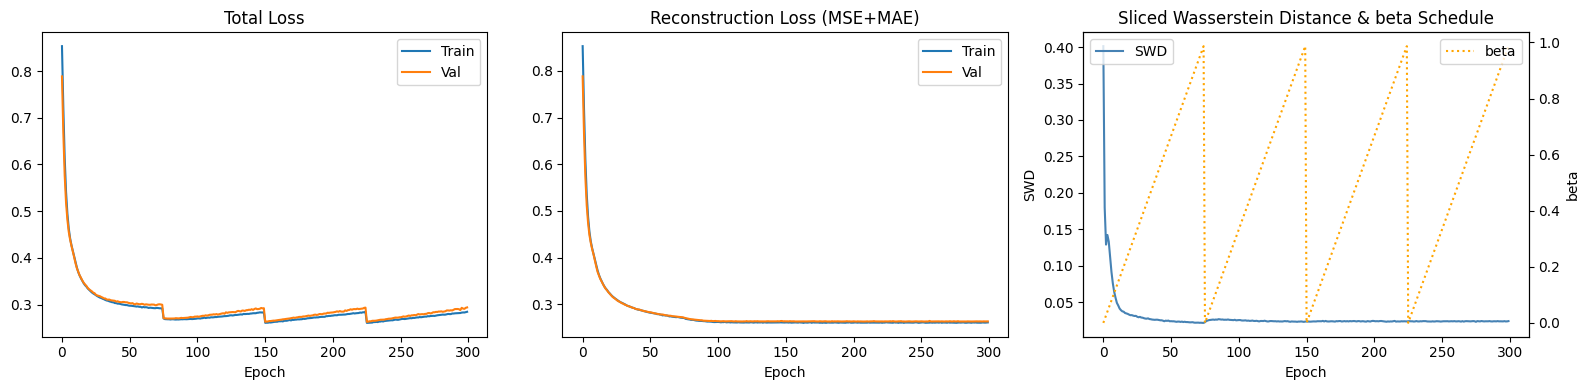

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val', linestyle='-')
axes[0].set_title('Total Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(history['train_recon'], label='Train')
axes[1].plot(history['val_recon'],   label='Val', linestyle='-')
axes[1].set_title('Reconstruction Loss (MSE+MAE)'); axes[1].legend(); axes[1].set_xlabel('Epoch')

ax2 = axes[2].twinx()
axes[2].plot(history['train_swd'], label='SWD', color='steelblue')
ax2.plot(history['beta'],          label='beta', color='orange', linestyle=':')
axes[2].set_title('Sliced Wasserstein Distance & beta Schedule')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('SWD'); ax2.set_ylabel('beta')
axes[2].legend(loc='upper left'); ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()

## 10. Generate Synthetic Patient Records

In [47]:
def build_condition_vector(age, gender_male, careunit, los_bucket, ccs_group, elix_flags=None):
    """
    Build a conditioning vector from human-readable inputs.

    Args:
        age         : int/float - patient age in years
        gender_male : bool
        careunit    : str  - e.g. 'MICU', 'SICU', 'CCU', 'CSRU', 'NICU'
        los_bucket  : str  - one of '<2d', '2-7d', '7-14d', '>14d'
        ccs_group   : str  - e.g. 'circulatory', 'respiratory', 'septicemia'
        elix_flags  : dict - optional {flag_name: 0/1}, e.g. {'chf': 1, 'renal_failure': 1}
    Returns:
        c_tensor : (1, C_DIM) scaled conditioning tensor on DEVICE
    """
    row = {col: 0.0 for col in COND_COLS}

    row['age']        = float(age)
    row['gender_bin'] = float(gender_male)

    icu_col = f'icu_{careunit}'
    if icu_col in row:
        row[icu_col] = 1.0

    los_col = f'los_{los_bucket}'
    if los_col in row:
        row[los_col] = 1.0

    ccs_col = f'ccs_{ccs_group}'
    if ccs_col in row:
        row[ccs_col] = 1.0

    if elix_flags:
        for k, v in elix_flags.items():
            ecol = f'elix_{k}'
            if ecol in row:
                row[ecol] = float(v)

    c_raw    = np.array([[row[col] for col in COND_COLS]], dtype=np.float32)
    c_scaled = c_scaler.transform(c_raw)
    return torch.tensor(c_scaled, dtype=torch.float32).to(DEVICE)


# -- Example: 68-year-old male, MICU, stays 2-7 days, circulatory diagnosis ---
c_example = build_condition_vector(
    age=68,
    gender_male=True,
    careunit='MICU',
    los_bucket='2-7d',
    ccs_group='circulatory',
    elix_flags={'chf': 1, 'hypertension': 1, 'renal_failure': 0}
)

# Generate 10 synthetic samples for this conditioning profile
synth_scaled = model.generate(c_example, n_samples=10).cpu().numpy()
synth_df     = pd.DataFrame(
    x_scaler.inverse_transform(synth_scaled),
    columns=FEATURE_COLS
)

print('Generated synthetic samples:')
synth_df.round(3)

Generated synthetic samples:


,glucose,sodium,potassium,creatinine,bun,bicarbonate,chloride,calcium_total,free_calcium,phosphate,...,lactate,hemoglobin,hematocrit,wbc,platelets,pt,ptt,bilirubin,ast,albumin
0,5.195,141.324997,3.820,0.670,19.547001,30.792999,102.930000,8.467,1.135,3.419,...,0.959,10.595,31.992001,11.147000,213.003998,2.677,3.373,0.502,3.666,3.224
1,4.675,137.259995,3.554,0.612,14.143000,22.676001,105.461998,7.926,1.119,2.932,...,0.954,11.198,32.518002,9.767000,158.557007,2.692,3.357,0.560,4.234,3.213
2,5.041,137.972000,3.536,0.542,13.519000,23.757000,106.802002,7.241,1.037,2.945,...,0.947,8.028,23.693001,16.254999,153.205002,2.892,3.721,0.777,3.496,2.928
3,4.514,130.063995,3.923,0.775,20.811001,19.558001,101.153999,6.514,1.069,3.046,...,0.857,10.500,30.593000,11.585000,155.947998,2.680,3.418,0.434,4.412,3.099
4,5.023,136.447006,5.103,1.567,85.392998,14.964000,99.837997,8.805,1.069,6.666,...,1.823,11.906,35.949001,21.399000,217.632996,3.063,3.633,1.498,4.432,3.243
5,5.783,128.123001,6.454,0.913,29.523001,25.575001,92.228996,9.403,1.125,3.774,...,1.219,11.693,34.756001,10.644000,244.906006,2.756,3.983,0.519,3.526,3.249
6,4.668,134.623993,6.392,1.222,38.667000,29.365999,94.948997,8.599,1.107,6.431,...,0.970,14.392,44.179001,13.615000,342.407990,2.784,3.412,0.489,3.670,3.075
7,4.647,139.970001,4.025,0.889,31.502001,19.687000,111.149002,9.433,1.210,3.582,...,0.942,9.230,27.659000,8.431000,140.688995,2.996,4.213,1.030,4.185,3.227
8,4.743,125.741997,4.494,0.911,29.424000,21.621000,94.408997,7.147,1.058,4.391,...,0.947,11.025,31.159000,12.469000,223.901001,2.722,4.913,0.466,4.817,2.690
9,5.332,131.145004,5.722,1.262,36.580002,26.108999,93.982002,8.221,1.074,5.581,...,1.081,9.036,28.039000,14.844000,292.829010,3.196,4.441,0.438,3.529,3.189


## 11. Fidelity Evaluation

We compare the marginal distributions of real vs. synthetic data and inspect the latent space geometry.

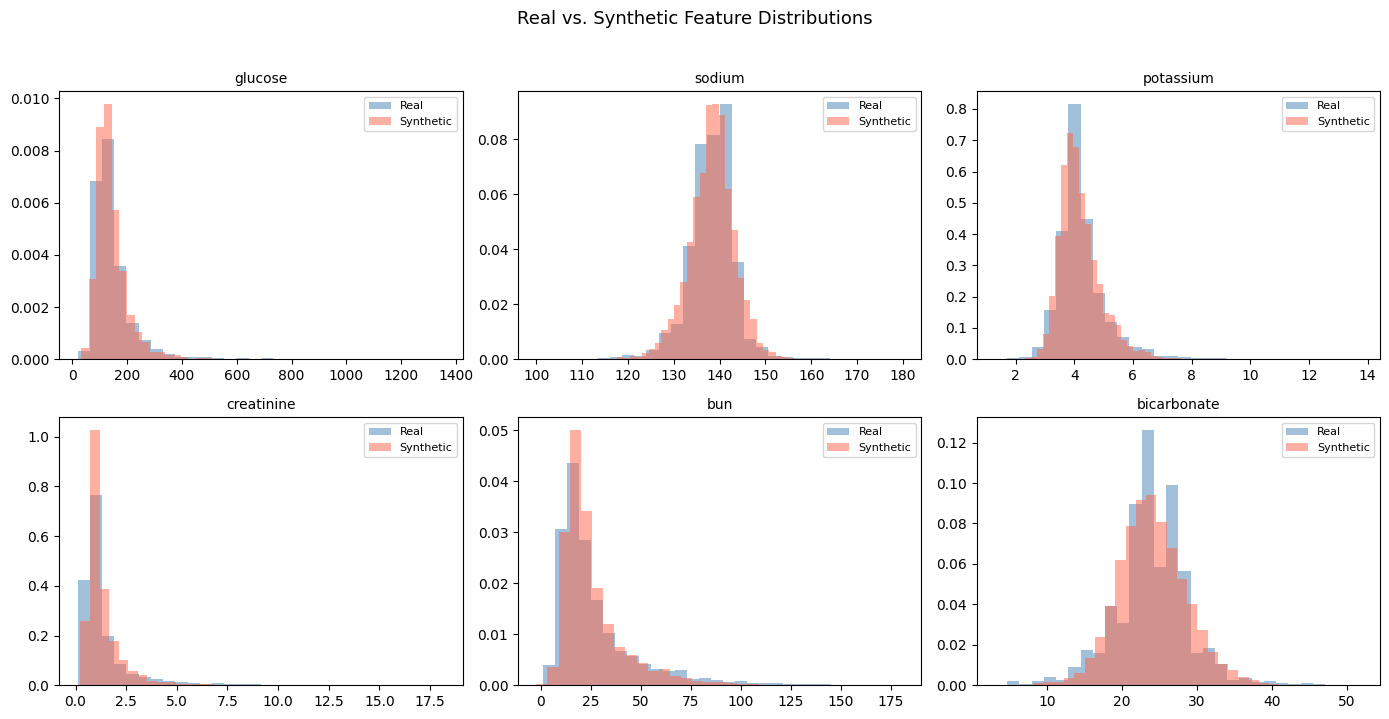

In [48]:
# -- Generate synthetic dataset matching real val set conditioning -------------
model.eval()
with torch.no_grad():
    synth_scaled_all = model.generate(C_val_t.to(DEVICE), n_samples=1).cpu().numpy()

real_df   = inverse_transform_labs(X_val)
synth_all = inverse_transform_labs(synth_scaled_all)

# Plot marginal distributions for first 6 features
plot_cols = FEATURE_COLS[:6]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    axes[i].hist(real_df[col],   bins=30, alpha=0.5, label='Real',      density=True, color='steelblue')
    axes[i].hist(synth_all[col], bins=30, alpha=0.5, label='Synthetic', density=True, color='tomato')
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=8)

plt.suptitle('Real vs. Synthetic Feature Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('distribution_comparison.png', dpi=120)
plt.show()

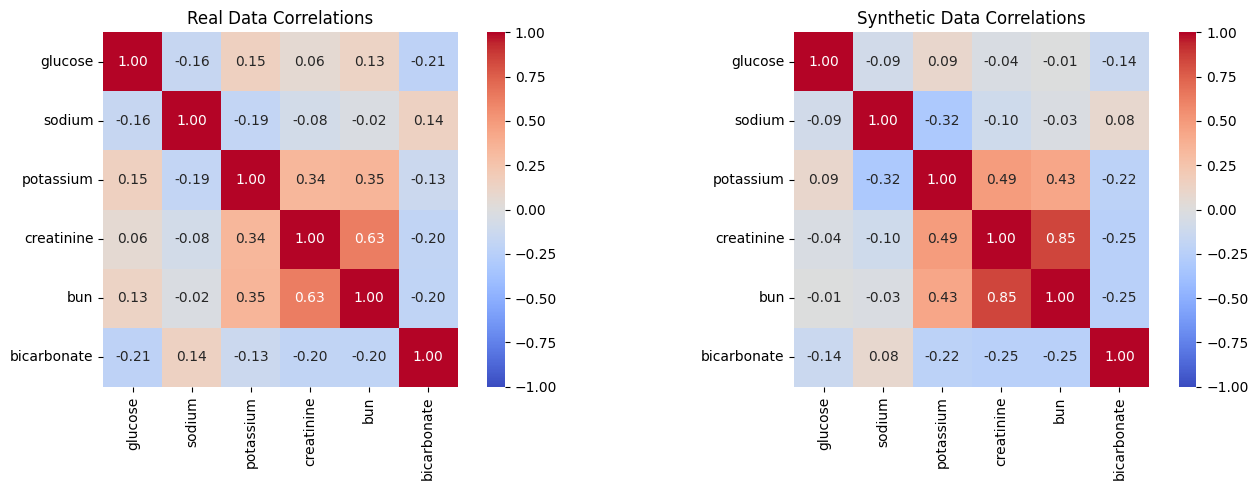

In [49]:
# -- Correlation matrix comparison --------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(real_df[plot_cols].corr(),   ax=axes[0], cmap='coolwarm',
            vmin=-1, vmax=1, annot=True, fmt='.2f', square=True)
axes[0].set_title('Real Data Correlations')

sns.heatmap(synth_all[plot_cols].corr(), ax=axes[1], cmap='coolwarm',
            vmin=-1, vmax=1, annot=True, fmt='.2f', square=True)
axes[1].set_title('Synthetic Data Correlations')

plt.tight_layout()
plt.savefig('correlation_comparison.png', dpi=120)
plt.show()

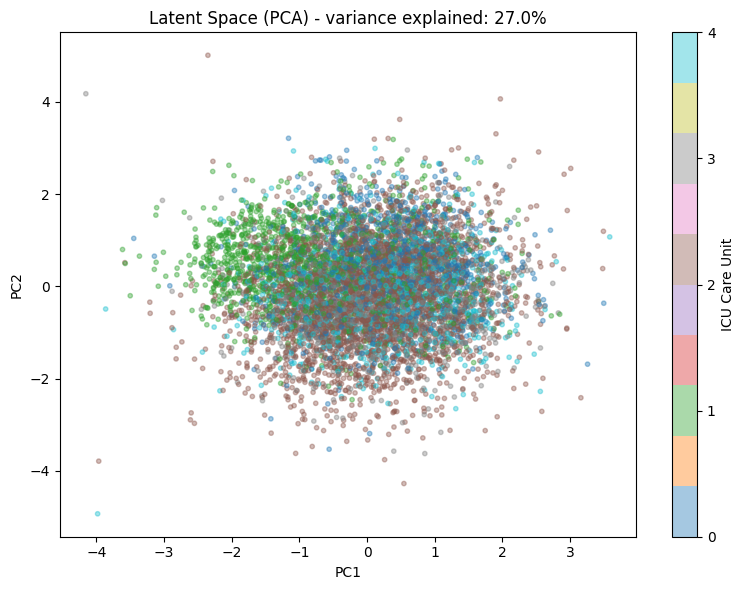

In [50]:
# -- Latent space PCA visualization -------------------------------------------
model.eval()
with torch.no_grad():
    z_val = model.encoder(X_val_t.to(DEVICE), C_val_t.to(DEVICE))

z_np = z_val.cpu().numpy()
pca  = PCA(n_components=2)
z_2d = pca.fit_transform(z_np)

# Color by ICU care unit if available
icu_cols = [c for c in COND_COLS if c.startswith('icu_')]
if icu_cols:
    labels = np.argmax(C_val[:, [COND_COLS.index(c) for c in icu_cols]], axis=1)
    label_names = [c.replace('icu_', '') for c in icu_cols]
else:
    labels = np.zeros(len(z_2d), dtype=int)
    label_names = ['all']

plt.figure(figsize=(8, 6))
scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=labels,
                       cmap='tab10', alpha=0.4, s=10)
plt.colorbar(scatter, ticks=range(len(label_names)),
             label='ICU Care Unit')
plt.title(f'Latent Space (PCA) - variance explained: '
          f'{pca.explained_variance_ratio_.sum():.1%}')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('latent_space_pca.png', dpi=120)
plt.show()

In [51]:
# Verify scaler was fit on training data only
print('X_train mean per lab:')
print(pd.Series(x_scaler.mean_, index=FEATURE_COLS).round(3))
print('\nX_train std per lab:')
print(pd.Series(x_scaler.scale_, index=FEATURE_COLS).round(3))

X_train mean per lab:
glucose            4.917
sodium           138.080
potassium          4.241
creatinine         0.802
bun               26.692
bicarbonate       23.860
chloride         103.974
calcium_total      8.442
free_calcium       1.116
phosphate          3.691
ph                 7.369
pco2              42.525
po2              182.239
lactate            1.087
hemoglobin        11.229
hematocrit        33.333
wbc               12.183
platelets        236.211
pt                 2.779
ptt                3.520
bilirubin          0.596
ast                3.789
albumin            3.204
dtype: float64

X_train std per lab:
glucose            0.413
sodium             5.079
potassium          0.845
creatinine         0.400
bun               22.042
bicarbonate        4.945
chloride           6.608
calcium_total      0.885
free_calcium       0.078
phosphate          1.334
ph                 0.085
pco2              11.228
po2              120.617
lactate            0.342
hemoglobin      

In [52]:
from scipy import stats

# Calculate KS statistic to see how close the real and synthetic data distributions are to each other
print('KS statistic per lab (lower is better):')
for col in LAB_COLS:
    ks_stat, _ = stats.ks_2samp(real_df[col], synth_all[col])
    quality = 'good' if ks_stat < 0.1 else 'acceptable' if ks_stat < 0.2 else 'POOR'
    print(f'  {col:16s}: KS={ks_stat:.3f}  {quality}')

KS statistic per lab (lower is better):
  glucose         : KS=0.063  good
  sodium          : KS=0.090  good
  potassium       : KS=0.069  good
  creatinine      : KS=0.145  acceptable
  bun             : KS=0.134  acceptable
  bicarbonate     : KS=0.076  good
  chloride        : KS=0.049  good
  calcium_total   : KS=0.095  good
  free_calcium    : KS=0.326  POOR
  phosphate       : KS=0.108  acceptable
  ph              : KS=0.185  acceptable
  pco2            : KS=0.244  POOR
  po2             : KS=0.185  acceptable
  lactate         : KS=0.268  POOR
  hemoglobin      : KS=0.042  good
  hematocrit      : KS=0.041  good
  wbc             : KS=0.074  good
  platelets       : KS=0.069  good
  pt              : KS=0.098  good
  ptt             : KS=0.093  good
  bilirubin       : KS=0.371  POOR
  ast             : KS=0.289  POOR
  albumin         : KS=0.335  POOR


## 12. Save Model & Scalers

In [53]:
import pickle, os

SAVE_DIR = 'cvae_outputs'
os.makedirs(SAVE_DIR, exist_ok=True)

# Model weights
torch.save(model.state_dict(), f'{SAVE_DIR}/cvae_weights_swd.pt')

# Scalers and column lists (needed to reproduce conditioning vectors)
with open(f'{SAVE_DIR}/scalers_and_cols_swd.pkl', 'wb') as f:
    pickle.dump({
        'x_scaler':           x_scaler,
        'c_scaler':           c_scaler,
        'feature_cols':       FEATURE_COLS,
        'cond_cols':          COND_COLS,
        'x_dim':              X_DIM,
        'c_dim':              C_DIM,
        'latent_dim':         LATENT_DIM,
        'log_transform_cols': LOG_TRANSFORM_COLS,
    }, f)

print(f'Saved model and metadata to ./{SAVE_DIR}/')

Saved model and metadata to ./cvae_outputs/


## 13. Reload & Inference Example

In [55]:
import pickle

with open(f'{SAVE_DIR}/scalers_and_cols_swd.pkl', 'rb') as f:
    meta = pickle.load(f)

loaded_model = cVAE(
    x_dim=meta['x_dim'],
    c_dim=meta['c_dim'],
    hidden_dims=(128, 64),
    latent_dim=meta['latent_dim']
).to(DEVICE)
loaded_model.load_state_dict(torch.load(f'{SAVE_DIR}/cvae_weights_swd.pt', map_location=DEVICE))
loaded_model.eval()

# Generate for a new patient profile: 45yo female, SICU, long stay, septicemia
c_new = build_condition_vector(
    age=45,
    gender_male=False,
    careunit='SICU',
    los_bucket='>14d',
    ccs_group='infectious',
    elix_flags={'septicemia': 1, 'renal_failure': 1, 'diabetes_uncomp': 0}
)

synth_new = loaded_model.generate(c_new, n_samples=5).cpu().numpy()
synth_new_df = inverse_transform_labs(synth_new)
print('Generated records for 45yo female SICU septicemia patient:')
synth_new_df.round(3)

Generated records for 45yo female SICU septicemia patient:


,glucose,sodium,potassium,creatinine,bun,bicarbonate,chloride,calcium_total,free_calcium,phosphate,...,lactate,hemoglobin,hematocrit,wbc,platelets,pt,ptt,bilirubin,ast,albumin
0,146.173004,146.966995,4.175,1.535,33.180000,18.711000,116.459000,8.390,1.137,4.040,...,3.879,11.502,35.326000,14.789000,192.106995,16.441999,37.990002,0.678,38.900002,2.881
1,189.218002,139.697998,4.421,1.511,24.971001,22.139000,106.441002,8.650,1.182,3.823,...,2.565,11.495,33.897999,16.327999,272.821991,14.264000,27.733999,0.640,38.779999,3.197
2,105.935997,138.789001,3.795,1.884,24.311001,18.968000,108.052002,9.764,1.141,3.573,...,4.177,8.499,25.913000,14.009000,126.200996,28.136999,112.539001,2.212,80.982002,3.224
3,145.811996,147.126007,3.876,1.192,29.190001,19.792999,116.966003,8.951,1.222,3.007,...,1.851,10.083,30.226000,17.731001,209.414993,13.669000,27.506001,0.690,30.958000,3.256
4,163.781998,138.367004,4.175,1.345,20.370001,20.697001,105.462997,9.117,1.235,3.342,...,4.305,11.818,34.765999,8.909000,161.175003,15.051000,42.423000,0.676,37.401001,3.141


---
## Architecture & Design Summary

| Component | Choice | Rationale |
|---|---|---|
| Conditioning input | Concatenation at encoder & decoder | Standard cVAE; simple and effective |
| ICD-9 representation | Coarse CCS grouping | Reduces 15k codes to ~19 clinically coherent groups |
| Comorbidity representation | 31-dim Elixhauser binary flags | Validated, interpretable, widely used |
| ICU unit | One-hot of first_careunit (NICU excluded) | Encodes patient severity profile; NICU excluded as neonatal population is incomparable to adult ICU |
| LOS | Bucketed one-hot | Avoids making generation contingent on exact float |
| Regularization | Sliced Wasserstein Distance (SWD) | Replaces KL divergence; always finite, no posterior collapse risk, better tail coverage |
| SWD schedule | Cyclical annealing beta: 0 to 1 over 75-epoch cycles | Allows reconstruction to stabilize before regularization pressure builds each cycle |
| Reconstruction loss | 0.5 * MSE + 0.5 * MAE | MSE handles typical patients; MAE reduces mean-regression bias and improves tail coverage |
| Normalization | BatchNorm on all hidden layers + warmup pass after training | Stabilizes training with heterogeneous clinical data; warmup corrects running statistics before generation |
| Latent dim | 8 | Balances expressiveness vs regularity; reduced from 16 to eliminate idle dimensions inflating SWD |
| Lab transforms | log1p on 7 right-skewed labs (glucose, creatinine, lactate, PT, PTT, bilirubin, AST) | Reduces skewness before StandardScaler normalization; expm1 applied at generation time |
| Cohort definition | Adult ICU admissions with labs in first 24hr window | Excludes NICU, no-lab admissions, and upstream FLAG-filtered records |